# 📊 Notebook 01 — Exploratory Data Analysis
### Telecom Churn Intelligence + LLM Retention Engine
**Dataset:** Cell2Cell Telecom Churn (51,047 customers · 58 features)

---

## Part 1 — Setup & Loading

In [60]:
# Step 1 — Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Libraries imported')

✅ Libraries imported


In [61]:
# Step 2 — Load the dataset (training file only)
df = pd.read_csv('/kaggle/input/datasets/mayssanefzi/telecochurn11/cell2celltrain.csv')

print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} customers')
print(f'Columns: {df.shape[1]} features')
df.head()

Shape: (51047, 58)
Rows: 51,047 customers
Columns: 58 features


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


## Part 2 — First Look at the Data

In [62]:
# Step 3 — Understand the structure
print('=== DATA TYPES & NON-NULL COUNTS ===')
print(df.info())
print()
print('=== STATISTICAL SUMMARY ===')
df.describe()

=== DATA TYPES & NON-NULL COUNTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerC

,CustomerID,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,...,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating
count,5.104700e+04,50891.000000,50891.000000,50891.000000,50891.000000,50891.000000,50891.000000,50680.000000,50680.000000,51047.000000,...,51046.000000,51046.000000,51046.000000,50138.000000,50138.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000
mean,3.201957e+06,58.834492,525.653416,46.830088,0.895229,40.027785,1.236244,-11.547908,-1.191985,6.011489,...,1.805646,1.558751,380.545841,31.338127,21.144142,0.037201,0.018277,0.052070,4.324524,0.053911
std,1.169056e+05,44.507336,529.871063,23.848871,2.228546,96.588076,9.818294,257.514772,39.574915,9.043955,...,1.331173,0.905932,253.801982,22.094635,23.931368,0.206483,0.142458,0.307592,3.138236,0.383147
min,3.000002e+06,-6.170000,0.000000,-11.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.700000,0.000000,...,1.000000,1.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.100632e+06,33.610000,158.000000,30.000000,0.000000,0.000000,0.000000,-83.000000,-7.100000,0.700000,...,1.000000,1.000000,205.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.201534e+06,48.460000,366.000000,45.000000,0.250000,3.000000,0.000000,-5.000000,-0.300000,3.000000,...,1.000000,1.000000,329.000000,36.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000
75%,3.305376e+06,71.065000,723.000000,60.000000,0.990000,41.000000,0.300000,66.000000,1.600000,7.700000,...,2.000000,2.000000,515.000000,48.000000,42.000000,0.000000,0.000000,0.000000,7.000000,0.000000
max,3.399994e+06,1223.380000,7359.000000,400.000000,159.390000,4321.000000,1112.400000,5192.000000,2483.500000,221.700000,...,24.000000,15.000000,1812.000000,99.000000,99.000000,4.000000,3.000000,35.000000,9.000000,25.000000


Total columns with missing values: 14
                       Missing Count  Missing %
AgeHH2                           909       1.78
AgeHH1                           909       1.78
PercChangeRevenues               367       0.72
PercChangeMinutes                367       0.72
MonthlyRevenue                   156       0.31
MonthlyMinutes                   156       0.31
RoamingCalls                     156       0.31
OverageMinutes                   156       0.31
DirectorAssistedCalls            156       0.31
TotalRecurringCharge             156       0.31
ServiceArea                       24       0.05
Handsets                           1       0.00
CurrentEquipmentDays               1       0.00
HandsetModels                      1       0.00


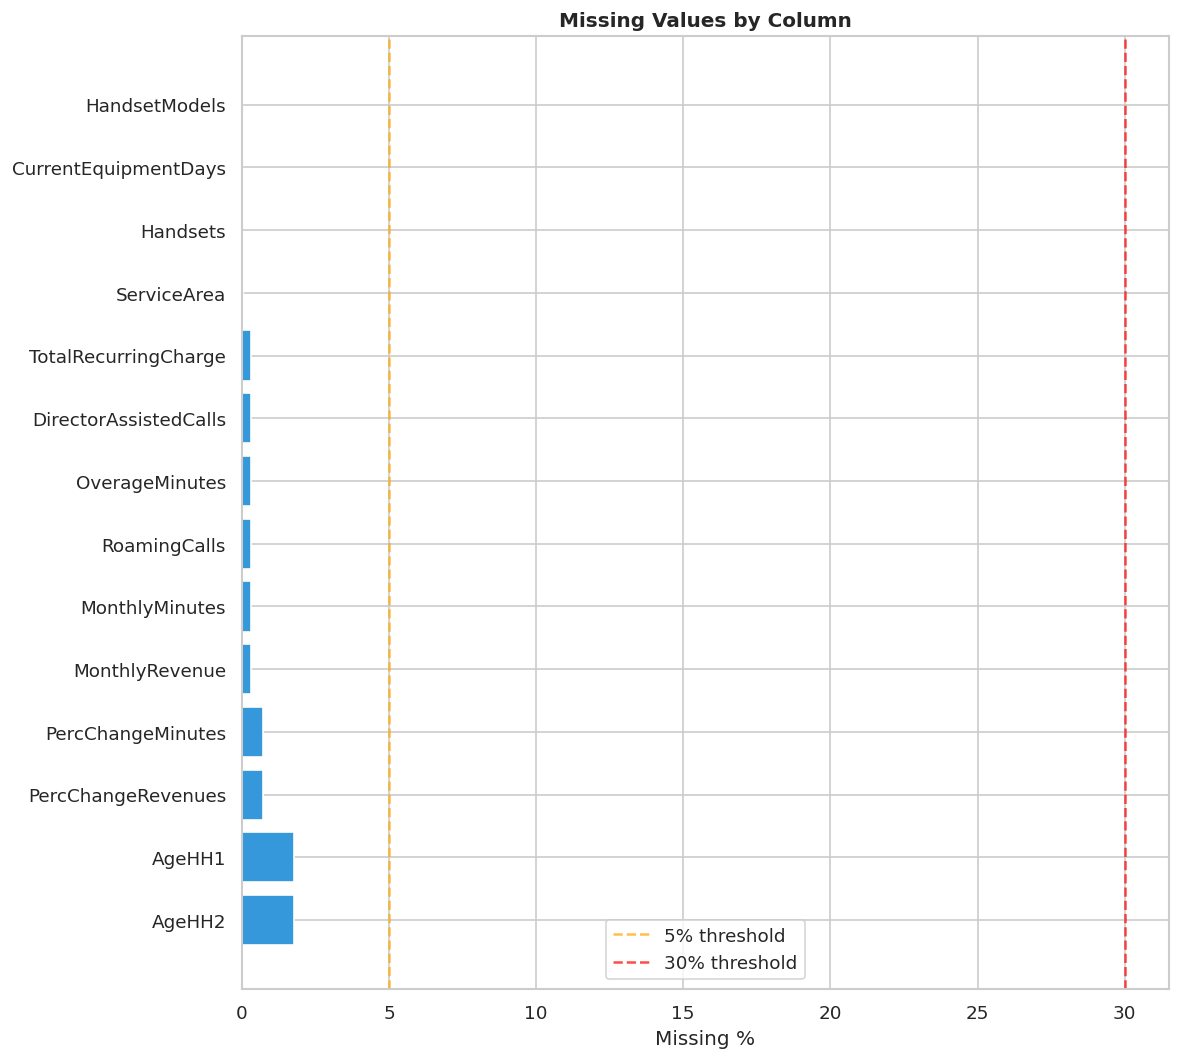

In [63]:
# Step 4 — Check missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Total columns with missing values: {len(missing_df)}')
print(missing_df)

# Visualize
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, len(missing_df) * 0.5 + 2))
    colors = ['#e74c3c' if x > 30 else '#f39c12' if x > 5 else '#3498db'
              for x in missing_df['Missing %']]
    ax.barh(missing_df.index, missing_df['Missing %'], color=colors)
    ax.axvline(5, color='orange', linestyle='--', alpha=0.7, label='5% threshold')
    ax.axvline(30, color='red', linestyle='--', alpha=0.7, label='30% threshold')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('missing_values.png', bbox_inches='tight')
    plt.show()

In [64]:
# Step 5 — Check the target variable: Churn
print('=== CHURN VALUE COUNTS ===')
print(df['Churn'].value_counts())
print()
print('=== CHURN PROPORTIONS ===')
print(df['Churn'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Convert to binary
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f'\nChurn rate: {df["Churn_Binary"].mean()*100:.1f}%')

=== CHURN VALUE COUNTS ===
Churn
No     36336
Yes    14711
Name: count, dtype: int64

=== CHURN PROPORTIONS ===
Churn
No     71.18%
Yes    28.82%
Name: proportion, dtype: object

Churn rate: 28.8%


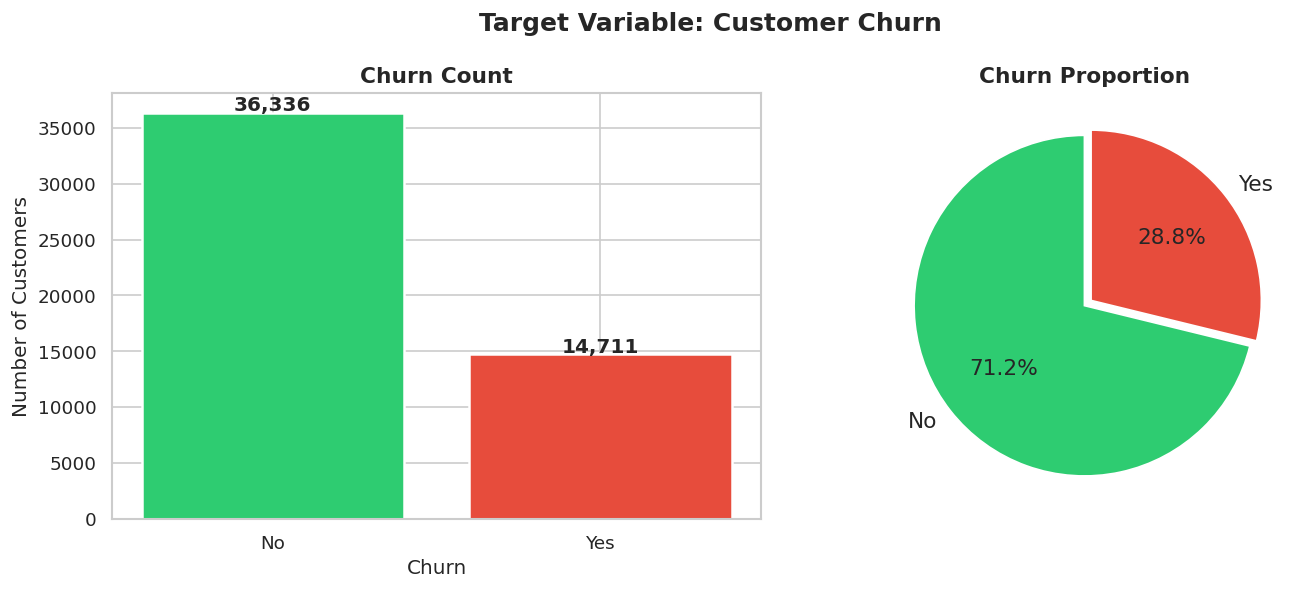


📌 Insight: ~29% churn rate — manageable imbalance.
   SMOTE is optional here but will still improve model performance.


In [65]:
# Step 5 continued — Visualize Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']

# Bar chart
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Count', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{val:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 13},
            explode=(0, 0.05))
axes[1].set_title('Churn Proportion', fontweight='bold', fontsize=13)

plt.suptitle('Target Variable: Customer Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_distribution.png', bbox_inches='tight')
plt.show()

print('\n📌 Insight: ~29% churn rate — manageable imbalance.')
print('   SMOTE is optional here but will still improve model performance.')

## Part 3 — Univariate Analysis

In [66]:
# Step 6 — Analyze numerical features

# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'Churn_Binary']
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'Churn']

print(f'Numerical columns: {len(num_cols)}')
print(f'Categorical columns: {len(cat_cols)}')

Numerical columns: 35
Categorical columns: 22


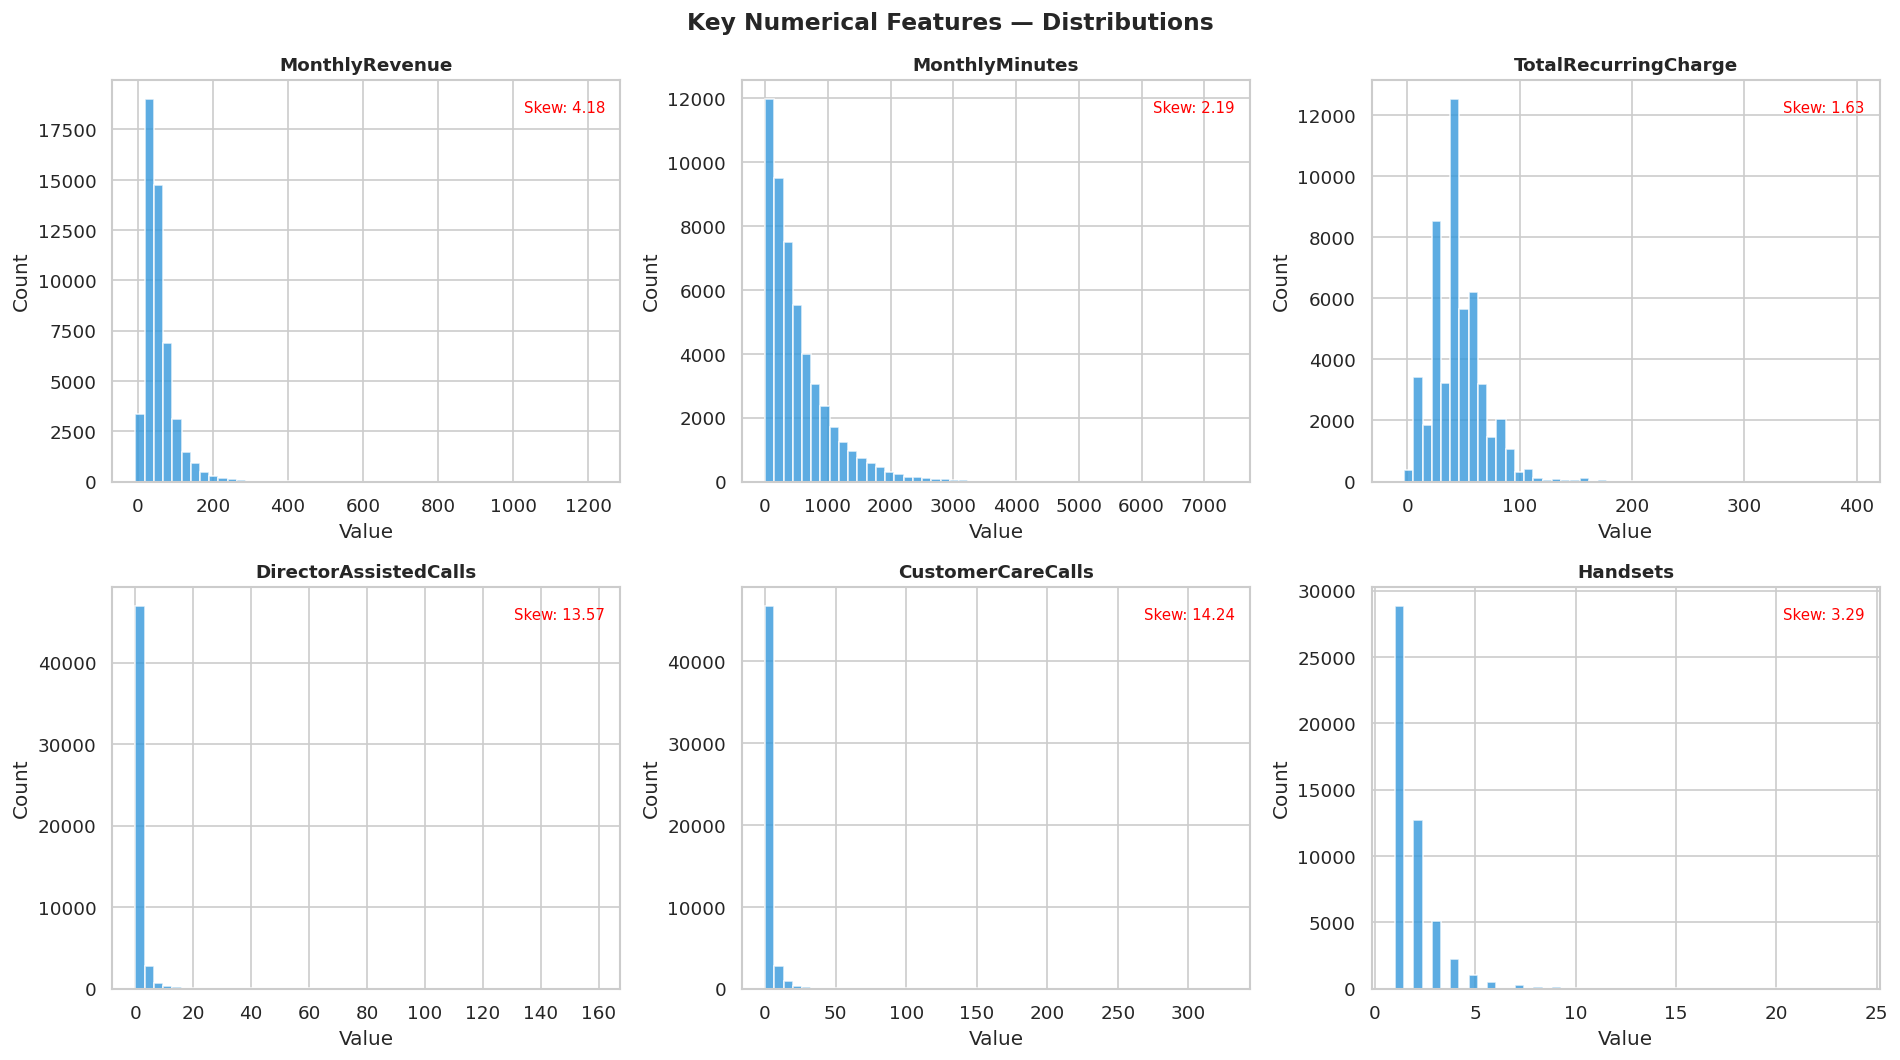


📌 Skewness of all numerical features:
Features with high skew (|skew| > 1): 30
CallForwardingCalls          91.63
UniqueSubs                   79.64
RoamingCalls                 57.88
ReferralsMadeBySubscriber    36.74
AdjustmentsToCreditRating    18.62
ThreewayCalls                17.55
CustomerCareCalls            14.24
DirectorAssistedCalls        13.57
CallWaitingCalls             11.12
ActiveSubs                   10.65
BlockedCalls                  9.79
RetentionOffersAccepted       8.70
OverageMinutes                8.11
PercChangeRevenues            7.89
RetentionCalls                6.30
InboundCalls                  5.93
DroppedBlockedCalls           5.52
DroppedCalls                  4.55
UnansweredCalls               4.38
MonthlyRevenue                4.18
OutboundCalls                 3.53
OffPeakCallsInOut             3.49
PeakCallsInOut                3.33
Handsets                      3.29
ReceivedCalls                 3.12
HandsetModels                 2.41
MonthlyMin

In [67]:
# Histograms for key numerical columns
key_num = ['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge',
           'DirectorAssistedCalls', 'CustomerCareCalls', 'Handsets']
key_num = [c for c in key_num if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(key_num[:6]):
    axes[i].hist(df[col].dropna(), bins=50,
                 color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    skew_val = df[col].skew()
    axes[i].text(0.97, 0.95, f'Skew: {skew_val:.2f}',
                 transform=axes[i].transAxes, ha='right', va='top',
                 fontsize=9, color='red' if abs(skew_val) > 1 else 'green')

plt.suptitle('Key Numerical Features — Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('numerical_distributions.png', bbox_inches='tight')
plt.show()

print('\n📌 Skewness of all numerical features:')
skew = df[num_cols].skew().sort_values(ascending=False)
high_skew = skew[abs(skew) > 1]
print(f'Features with high skew (|skew| > 1): {len(high_skew)}')
print(high_skew.round(2))

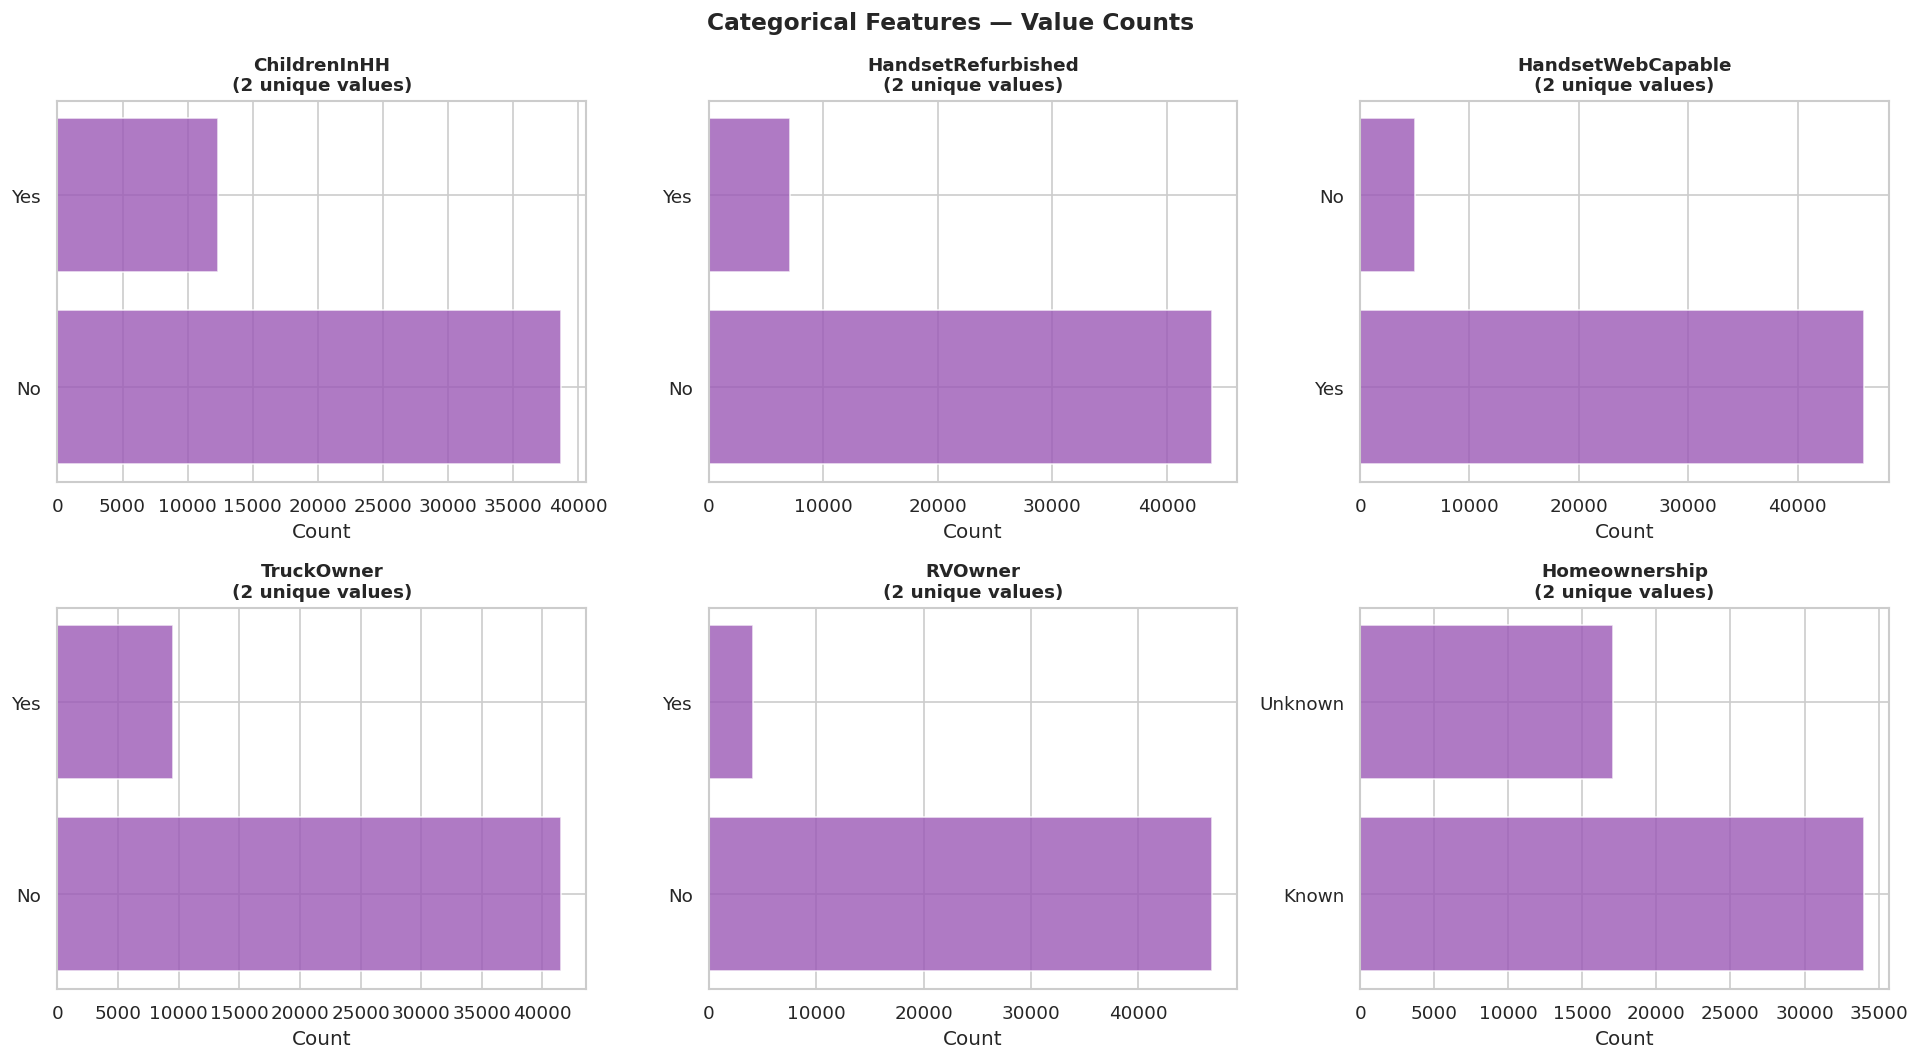


📌 Cardinality of categorical columns:
  ServiceArea: 747 unique values
  ChildrenInHH: 2 unique values
  HandsetRefurbished: 2 unique values
  HandsetWebCapable: 2 unique values
  TruckOwner: 2 unique values
  RVOwner: 2 unique values
  Homeownership: 2 unique values
  BuysViaMailOrder: 2 unique values
  RespondsToMailOffers: 2 unique values
  OptOutMailings: 2 unique values
  NonUSTravel: 2 unique values
  OwnsComputer: 2 unique values
  HasCreditCard: 2 unique values
  NewCellphoneUser: 2 unique values
  NotNewCellphoneUser: 2 unique values
  OwnsMotorcycle: 2 unique values
  HandsetPrice: 16 unique values
  MadeCallToRetentionTeam: 2 unique values
  CreditRating: 7 unique values
  PrizmCode: 4 unique values
  Occupation: 8 unique values
  MaritalStatus: 3 unique values


In [68]:
# Step 7 — Analyze categorical features
key_cat = [c for c in cat_cols if df[c].nunique() <= 10][:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(key_cat[:6]):
    counts = df[col].value_counts()
    axes[i].barh(counts.index.astype(str), counts.values,
                 color='#9b59b6', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col}\n({df[col].nunique()} unique values)',
                      fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Count')

plt.suptitle('Categorical Features — Value Counts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_distributions.png', bbox_inches='tight')
plt.show()

print('\n📌 Cardinality of categorical columns:')
for col in cat_cols:
    print(f'  {col}: {df[col].nunique()} unique values')

In [69]:
for i, col in enumerate(key_num_model[:6]):
    churned = df[df['Churn_Binary'] == 1][col].dropna()      # ✅ dropna here
    not_churned = df[df['Churn_Binary'] == 0][col].dropna()  # ✅ dropna here
    axes[i].boxplot([not_churned, churned], ...)

In [70]:
print(df['Churn'].value_counts())
print(df[['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge']].describe())

Churn
No     36336
Yes    14711
Name: count, dtype: int64
       MonthlyRevenue  MonthlyMinutes  TotalRecurringCharge
count    50891.000000    50891.000000          50891.000000
mean        58.834492      525.653416             46.830088
std         44.507336      529.871063             23.848871
min         -6.170000        0.000000            -11.000000
25%         33.610000      158.000000             30.000000
50%         48.460000      366.000000             45.000000
75%         71.065000      723.000000             60.000000
max       1223.380000     7359.000000            400.000000


## Part 4 — Bivariate Analysis

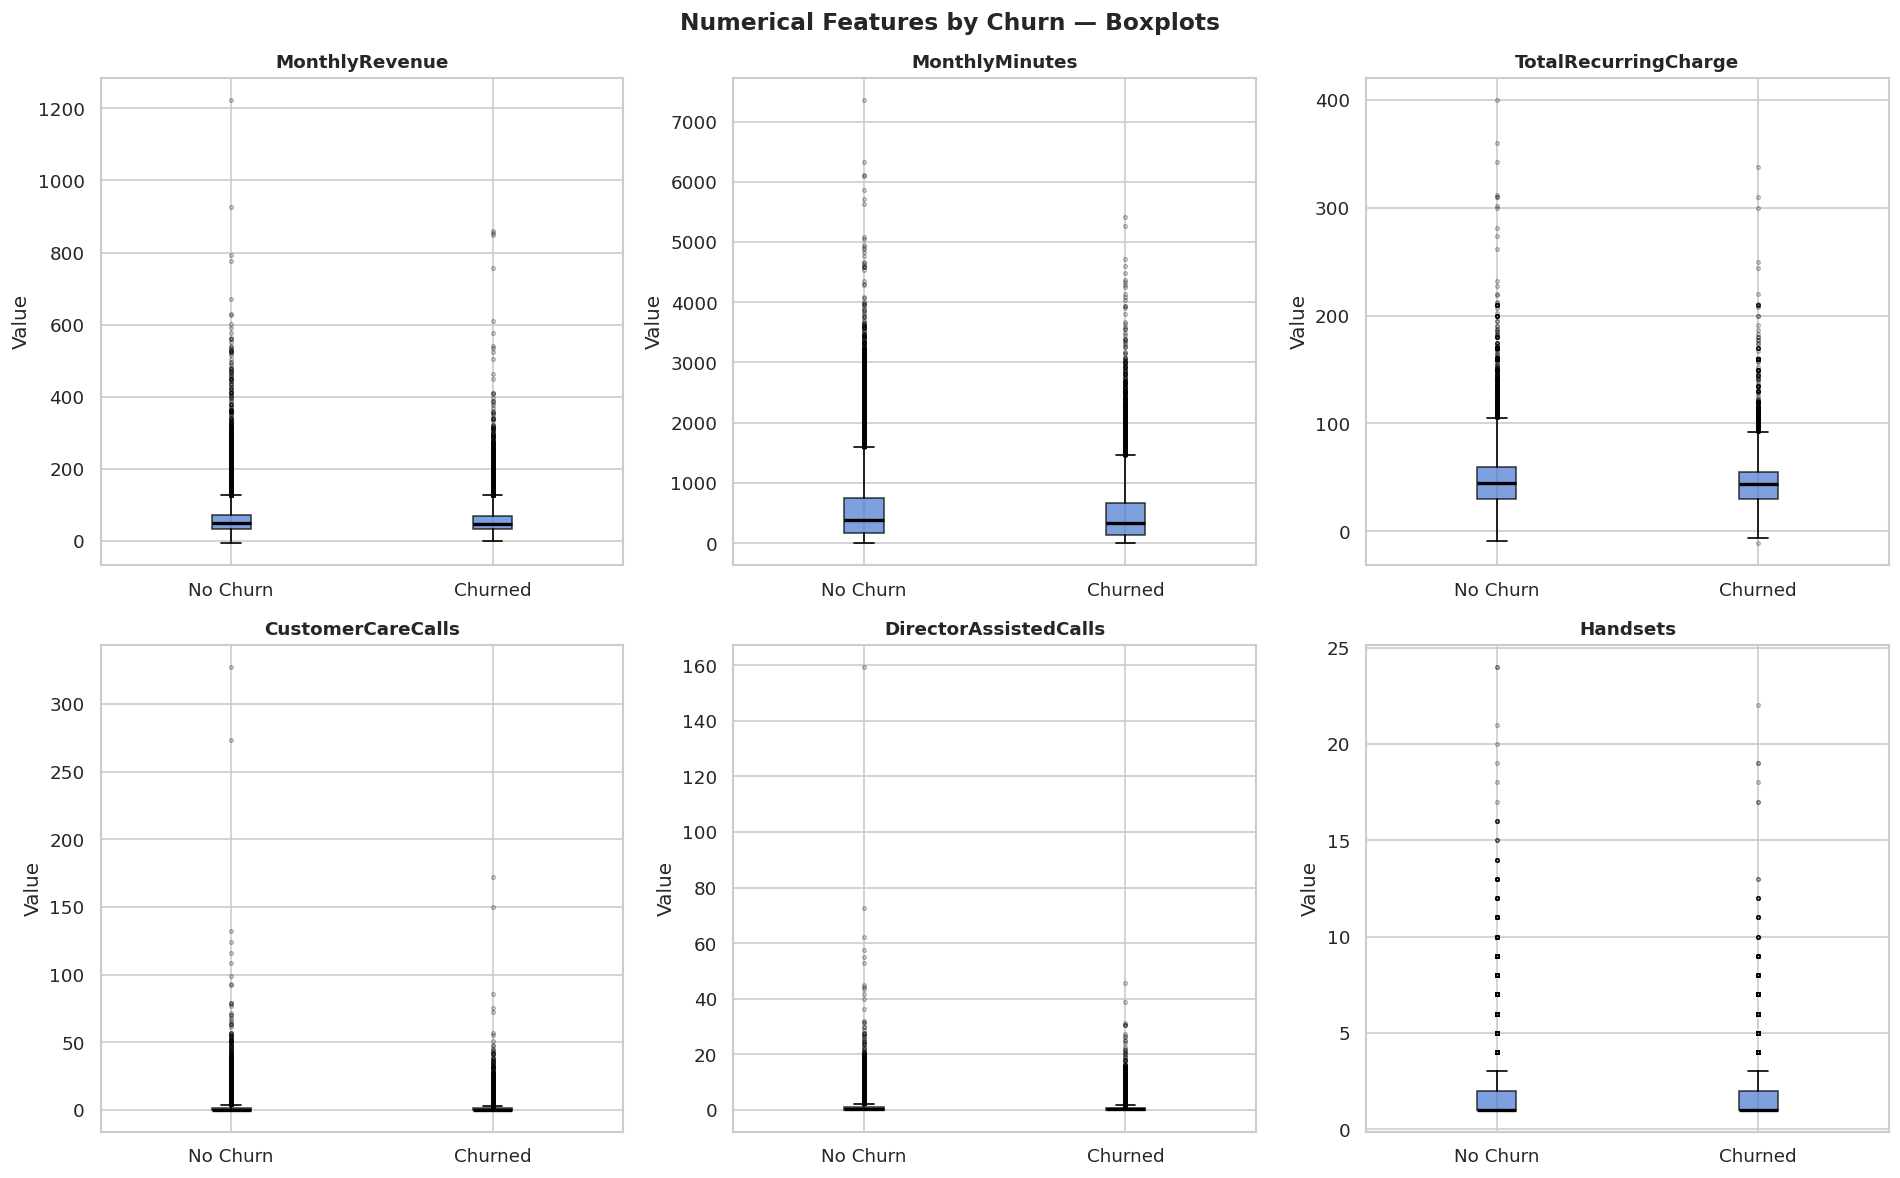


📌 Mean values by Churn:
       MonthlyRevenue  MonthlyMinutes  TotalRecurringCharge  \
Churn                                                         
No              59.17          542.55                 47.76   
Yes             58.00          483.83                 44.53   

       CustomerCareCalls  DirectorAssistedCalls  Handsets  
Churn                                                      
No                  1.98                   0.92      1.83  
Yes                 1.58                   0.83      1.74  


In [71]:
# Step 8 — Numerical features vs Churn
key_num_model = ['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge',
                 'CustomerCareCalls', 'DirectorAssistedCalls', 'Handsets']
key_num_model = [c for c in key_num_model if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# ✅ Use 'Churn' directly since Churn_Binary doesn't exist in NB01
for i, col in enumerate(key_num_model[:6]):
    churned = df[df['Churn'] == 'Yes'][col].dropna()
    not_churned = df[df['Churn'] == 'No'][col].dropna()
    axes[i].boxplot([not_churned, churned],
                    labels=['No Churn', 'Churned'],
                    patch_artist=True,
                    boxprops=dict(alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(markersize=2, alpha=0.3))
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Value')

plt.suptitle('Numerical Features by Churn — Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('numerical_vs_churn.png', bbox_inches='tight')
plt.show()

print('\n📌 Mean values by Churn:')
print(df.groupby('Churn')[key_num_model].mean().round(2))

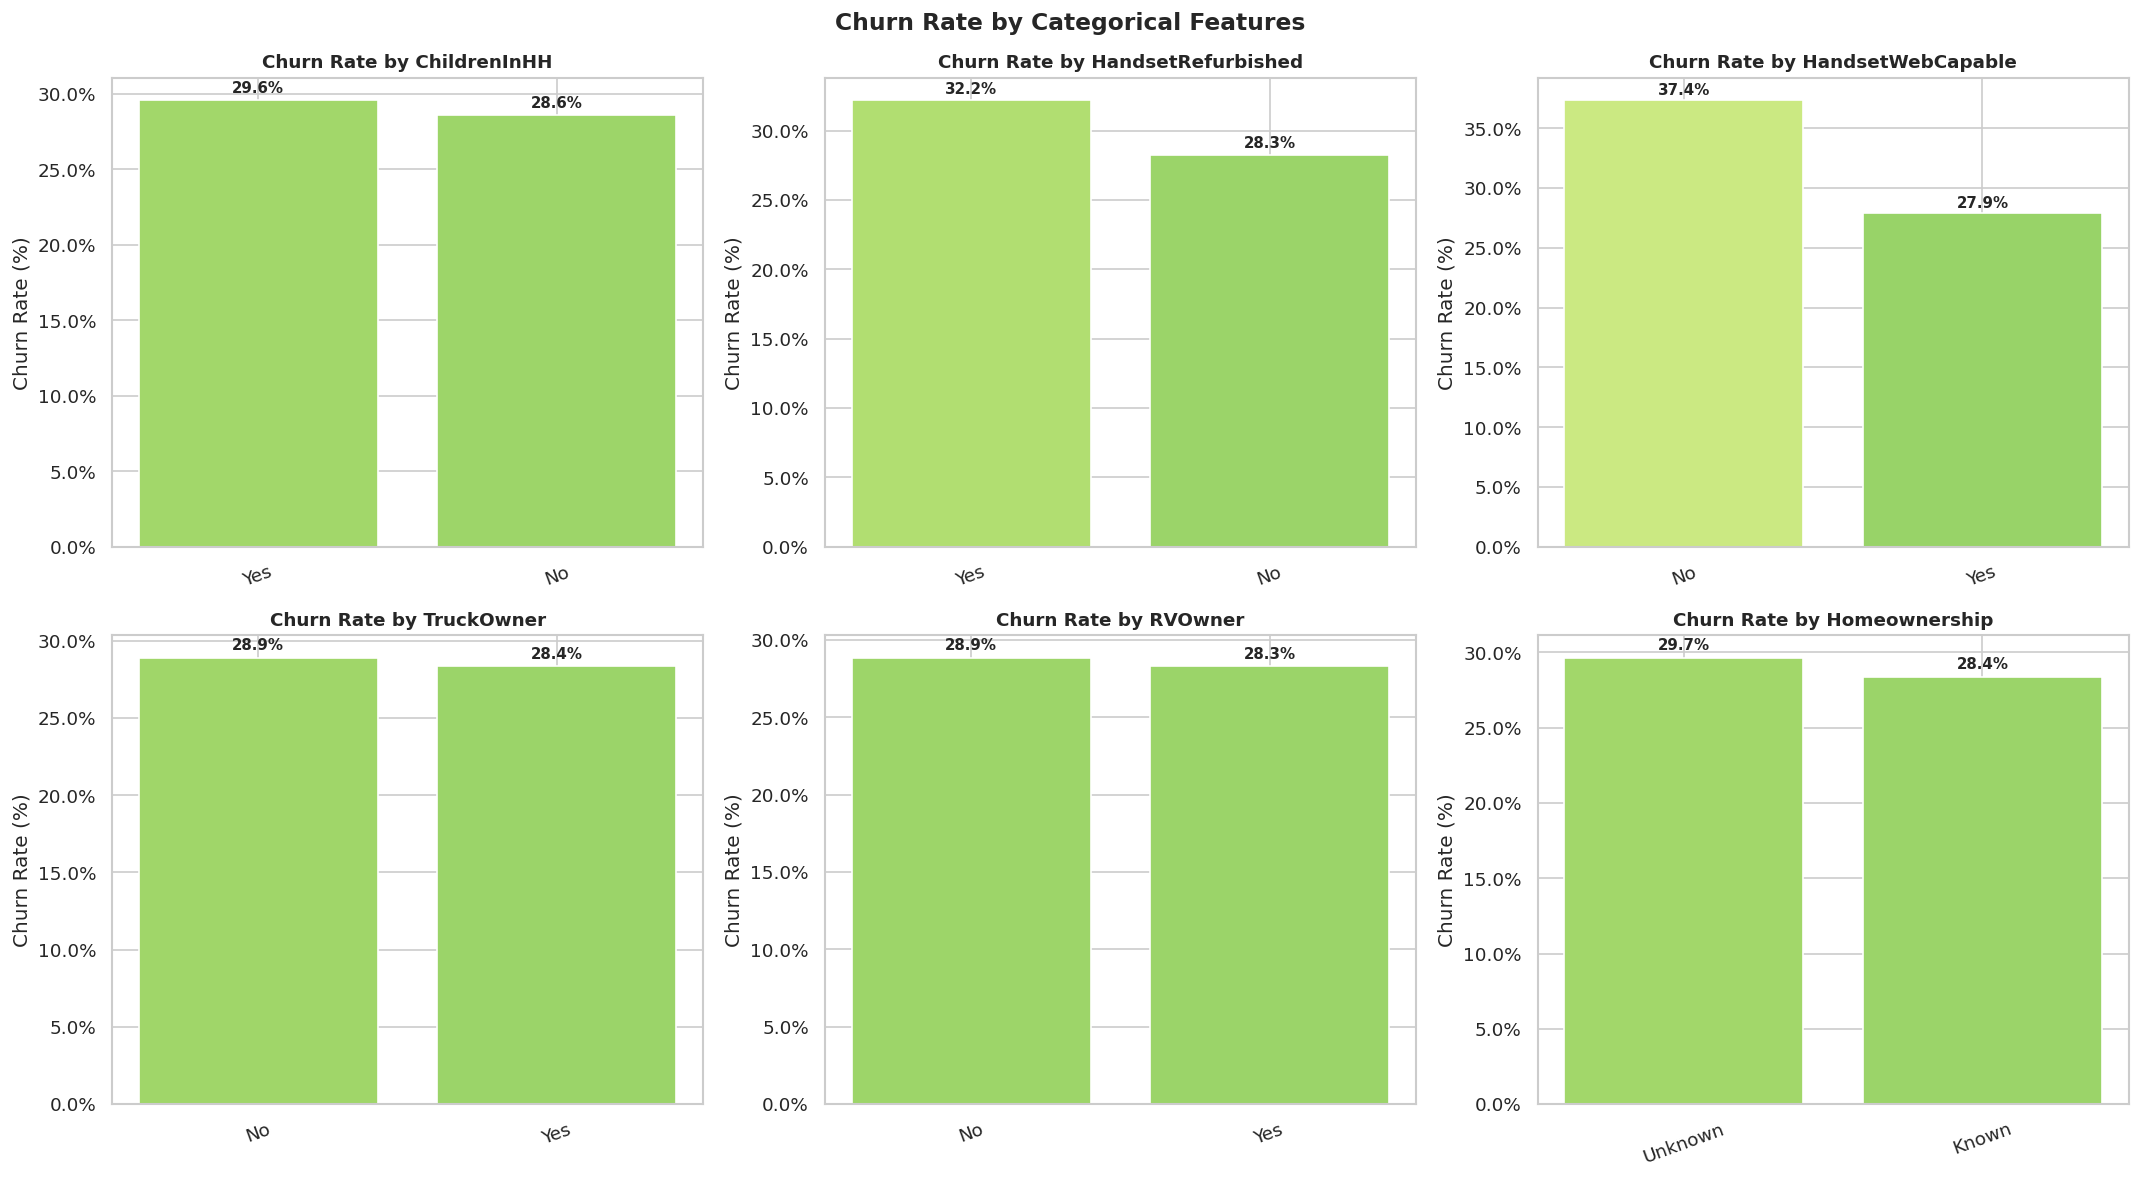

In [72]:
# Step 9 — Categorical features vs Churn rate
key_cat_model = [c for c in cat_cols if df[c].nunique() <= 10][:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_cat_model[:6]):
    churn_rate = df.groupby(col)['Churn_Binary'].mean().sort_values(ascending=False) * 100
    colors_bar = plt.cm.RdYlGn_r(churn_rate.values / 100)
    bars = axes[i].bar(churn_rate.index.astype(str), churn_rate.values,
                       color=colors_bar, edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_vs_churn.png', bbox_inches='tight')
plt.show()

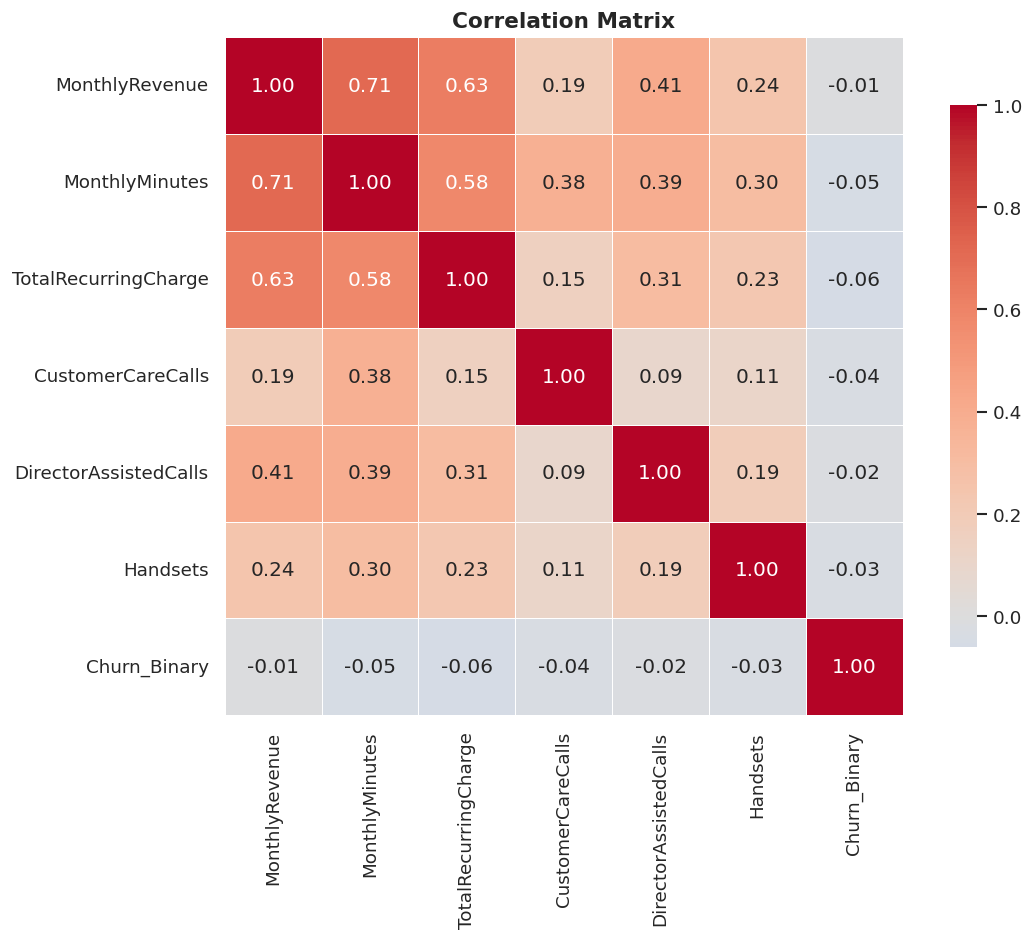


📌 Correlation with Churn (sorted):
TotalRecurringCharge    -0.061
MonthlyMinutes          -0.050
CustomerCareCalls       -0.036
Handsets                -0.033
DirectorAssistedCalls   -0.020
MonthlyRevenue          -0.012
Name: Churn_Binary, dtype: float64

📌 Highly correlated feature pairs (|corr| > 0.8):
  No highly correlated pairs found in selected features


In [73]:
# Step 10 — Correlation heatmap
# Select most relevant numerical columns to keep heatmap readable
top_num = key_num_model + ['Churn_Binary']
top_num = [c for c in top_num if c in df.columns]

corr_matrix = df[top_num].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('\n📌 Correlation with Churn (sorted):')
churn_corr = corr_matrix['Churn_Binary'].drop('Churn_Binary').sort_values()
print(churn_corr.round(3))

print('\n📌 Highly correlated feature pairs (|corr| > 0.8):')
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.8:
            corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(val, 3)))

if corr_pairs:
    for a, b, v in corr_pairs:
        print(f'  {a} <-> {b}: {v}')
else:
    print('  No highly correlated pairs found in selected features')

In [74]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Just to visualize the correlated features
correlated = ['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[correlated].dropna())

pca = PCA()
pca.fit(X_scaled)

# How much variance does each component explain?
print('Explained variance ratio:')
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f'  Component {i+1}: {v*100:.1f}%')

Explained variance ratio:
  Component 1: 76.2%
  Component 2: 14.4%
  Component 3: 9.4%


## PCA Confirmation

PCA on correlated numerical features (MonthlyRevenue, 
MonthlyMinutes, TotalRecurringCharge):

- Component 1 explains 76.2% of variance
- Components 1+2 explain 90.6% combined
- Conclusion: these 3 features are essentially 1 signal 
  ("customer activity level")

Modeling decision: drop MonthlyRevenue, retain MonthlyMinutes 
and TotalRecurringCharge for interpretability.
XGBoost chosen over logistic regression — more robust 
to this type of multicollinearity.

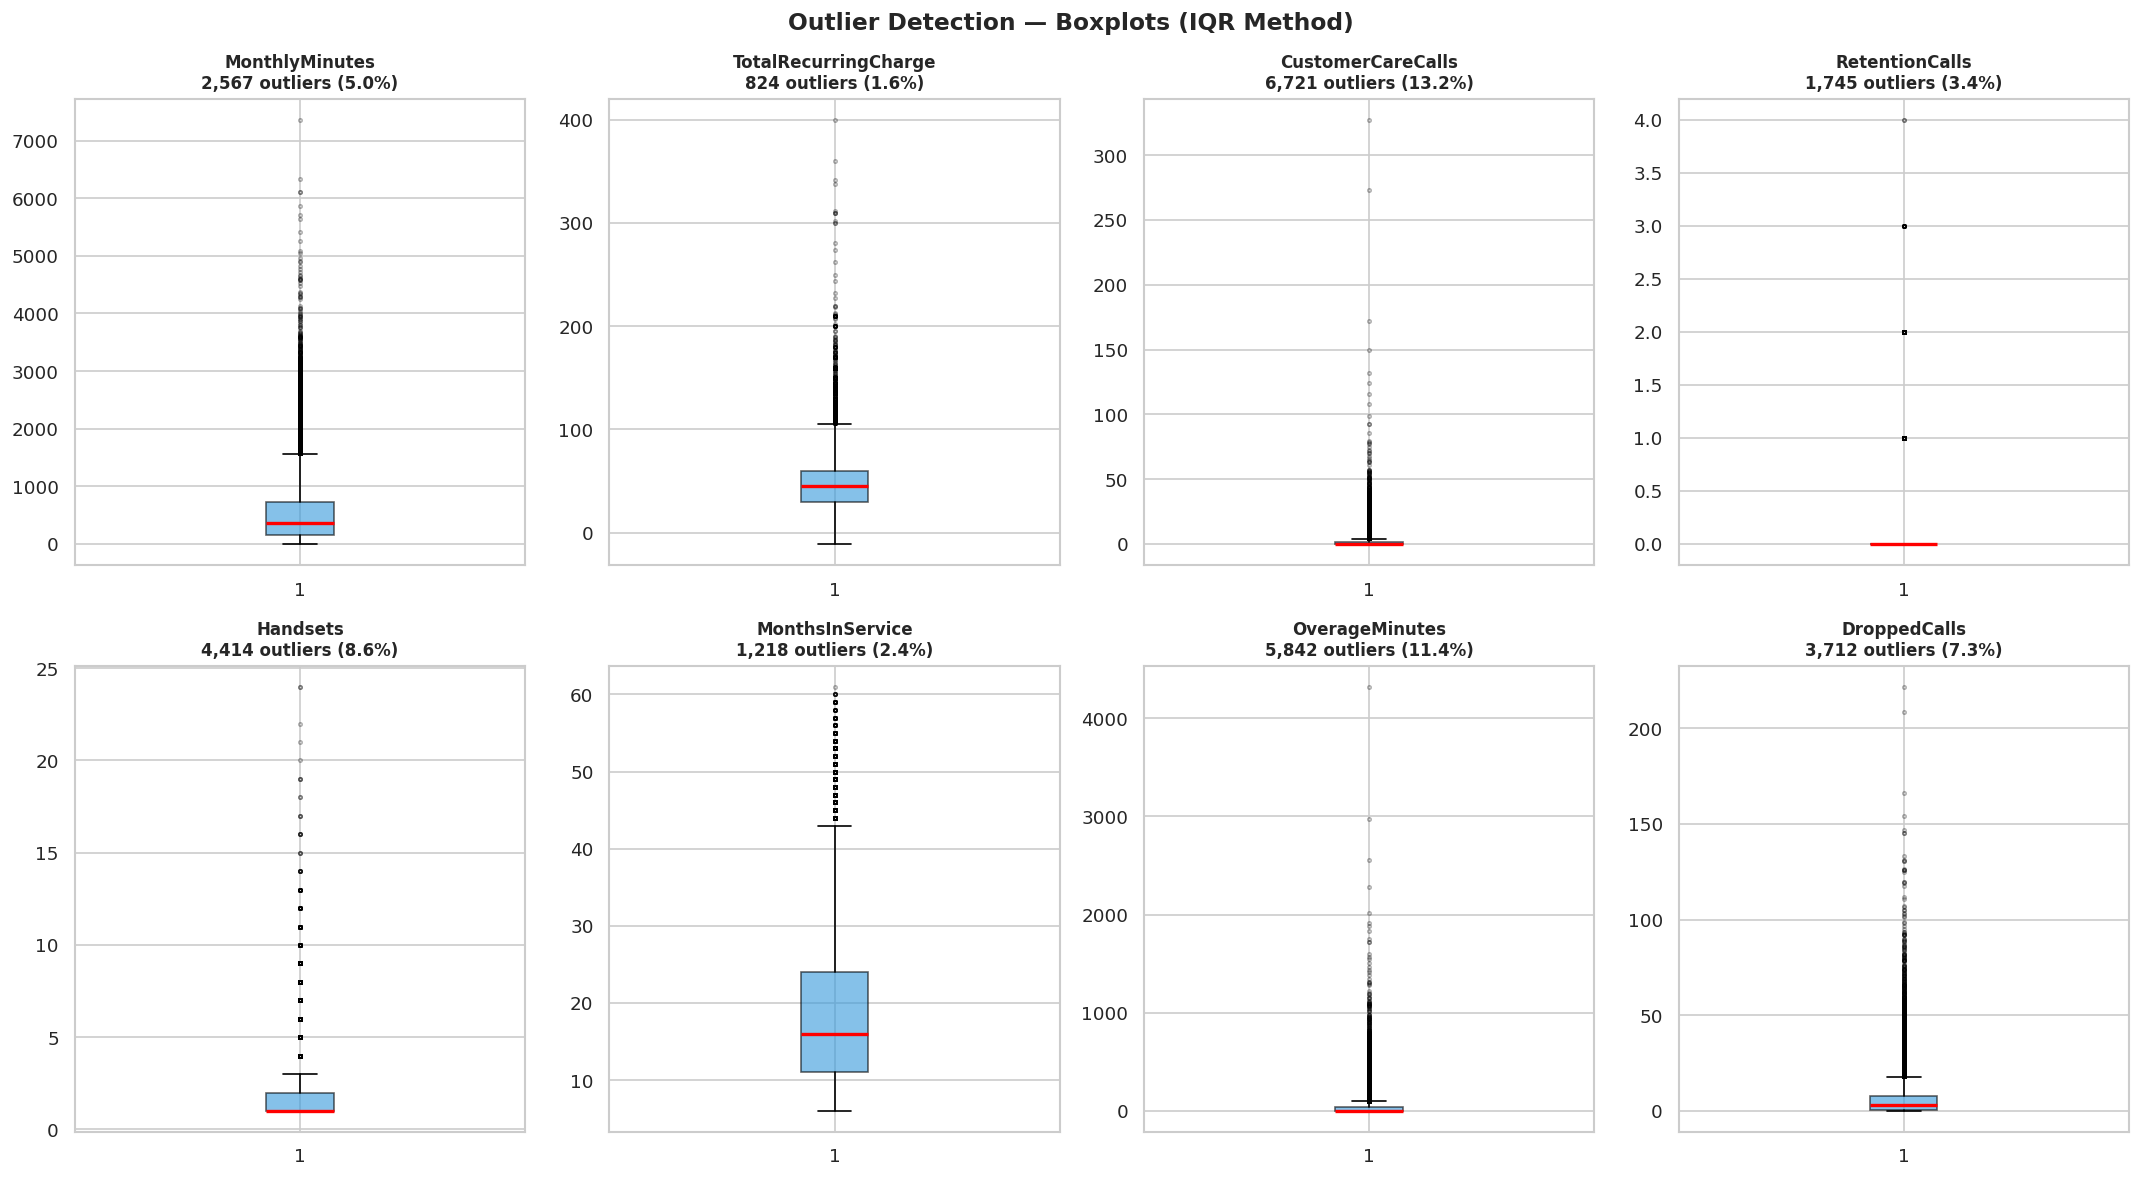

In [75]:
# ── Boxplots to spot outliers ──────────────────────────────────
key_num = ['MonthlyMinutes', 'TotalRecurringCharge', 'CustomerCareCalls',
           'RetentionCalls', 'Handsets', 'MonthsInService',
           'OverageMinutes', 'DroppedCalls']
key_num = [c for c in key_num if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_num):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_out = n_out / len(df) * 100

    axes[i].boxplot(df[col].dropna(),
                    patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=2,
                                   alpha=0.3, color='#e74c3c'))
    axes[i].set_title(f'{col}\n{n_out:,} outliers ({pct_out:.1f}%)',
                      fontweight='bold', fontsize=10)

plt.suptitle('Outlier Detection — Boxplots (IQR Method)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outliers_boxplot.png', bbox_inches='tight')
plt.show()

In [76]:
# ── Outlier summary table ──────────────────────────────────────
outlier_summary = []

for col in key_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'Feature': col,
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': n_out,
        'Outlier %': round(n_out / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier %', ascending=False)
print(outlier_df.to_string(index=False))

             Feature  Lower Bound  Upper Bound  Outlier Count  Outlier %
   CustomerCareCalls        -2.55         4.25           6721      13.17
      OverageMinutes       -61.50       102.50           5842      11.44
            Handsets        -0.50         3.50           4414       8.65
        DroppedCalls        -9.80        18.20           3712       7.27
      MonthlyMinutes      -689.50      1570.50           2567       5.03
      RetentionCalls         0.00         0.00           1745       3.42
     MonthsInService        -8.50        43.50           1218       2.39
TotalRecurringCharge       -15.00       105.00            824       1.61


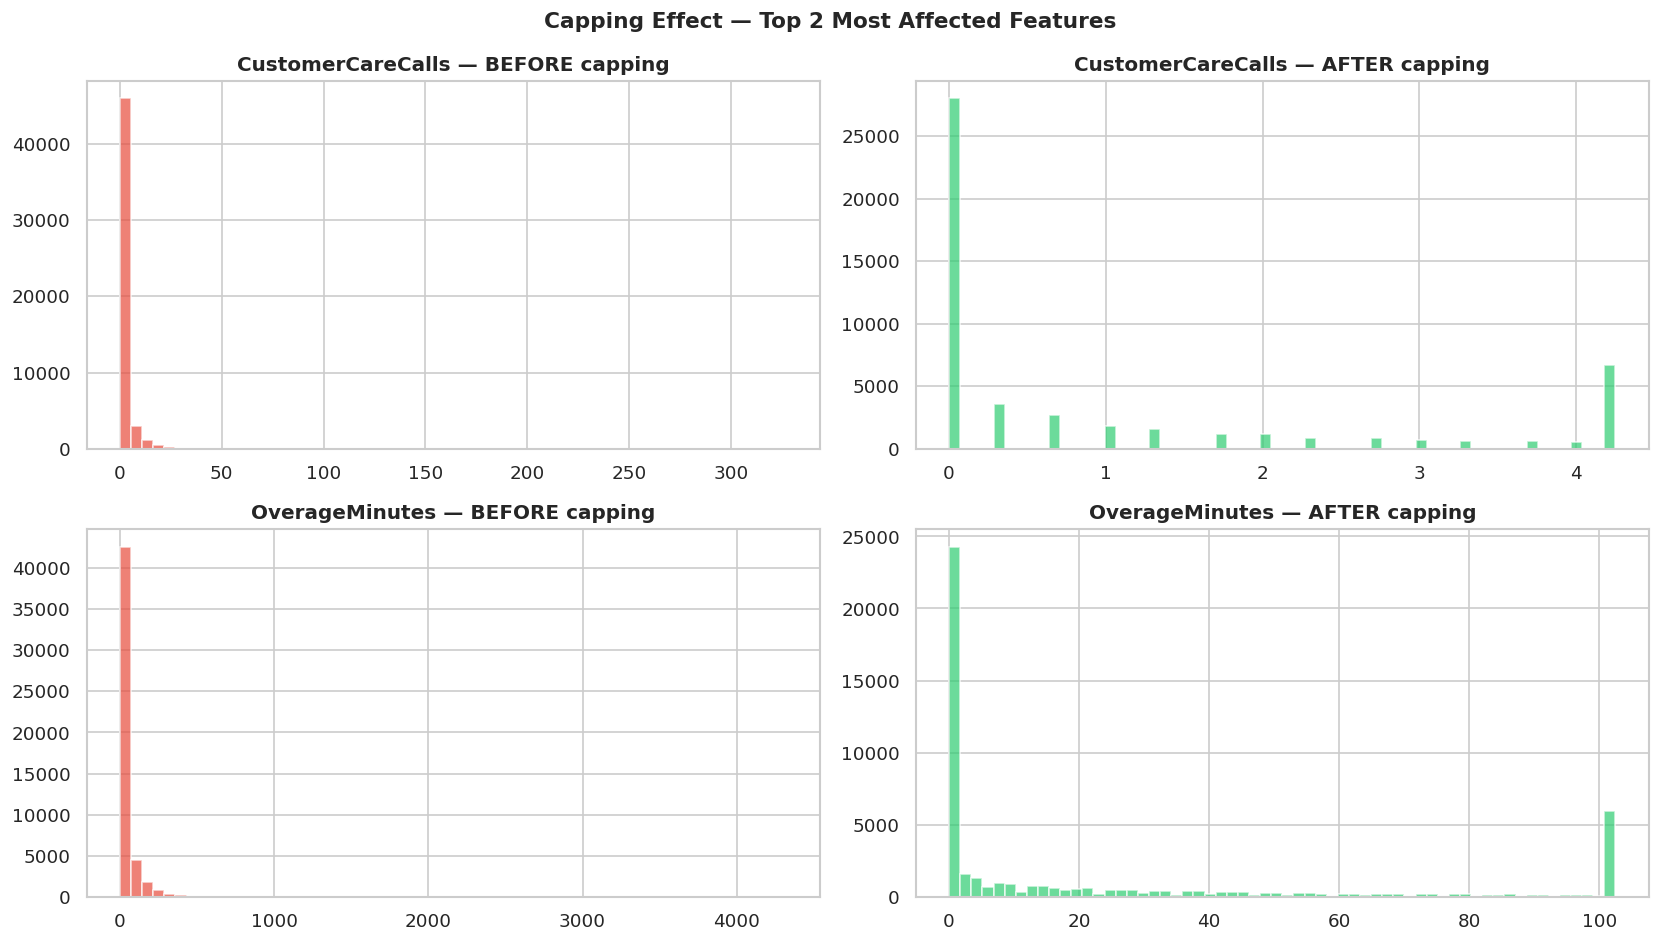

In [77]:
# ── Before vs After capping comparison ────────────────────────
top2 = outlier_df.head(2)['Feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(top2):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    capped = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

    axes[i, 0].hist(df[col].dropna(), bins=60,
                    color='#e74c3c', alpha=0.7, edgecolor='white')
    axes[i, 0].set_title(f'{col} — BEFORE capping', fontweight='bold')

    axes[i, 1].hist(capped, bins=60,
                    color='#2ecc71', alpha=0.7, edgecolor='white')
    axes[i, 1].set_title(f'{col} — AFTER capping', fontweight='bold')

plt.suptitle('Capping Effect — Top 2 Most Affected Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outlier_capping_effect.png', bbox_inches='tight')
plt.show()

## Part 5 — Summary & Next Steps

In [78]:
# Step 11 — EDA Summary
print('=' * 60)
print('         CELL2CELL EDA SUMMARY')
print('=' * 60)
print(f'  Total customers         : {len(df):,}')
print(f'  Features                : {df.shape[1]}')
print(f'  Churn rate              : {df["Churn_Binary"].mean()*100:.1f}%')
print(f'  Churned customers       : {df["Churn_Binary"].sum():,}')
print(f'  Missing values fixed    : ✅')
print(f'  Highly skewed features  : {len(df[num_cols].skew()[abs(df[num_cols].skew()) > 1])}')
print()

print('Top features correlated with Churn:')
top_pos = churn_corr.tail(3)
top_neg = churn_corr.head(3)
print('  Positive (churn increases with these):')
for feat, val in top_pos.items():
    print(f'    {feat}: {val:.3f}')
print('  Negative (churn decreases with these):')
for feat, val in top_neg.items():
    print(f'    {feat}: {val:.3f}')

print()
print('Action items for Notebook 02 (Segmentation):')
print('  1. Use numerical features: MonthlyRevenue, MonthlyMinutes, CustomerCareCalls')
print('  2. Scale features before KMeans (StandardScaler)')
print('  3. Try K = 3 to 6 clusters using elbow method')
print('  4. Label each cluster with a business name')
print()
print('Action items for Notebook 03 (Churn Prediction):')
print('  1. Encode categorical columns with pd.get_dummies()')
print('  2. Apply log transform to highly skewed features')
print('  3. Drop CustomerID and any columns with near-zero variance')
print('  4. Use XGBoost + evaluate with AUC-ROC and Precision-Recall')
print('=' * 60)

         CELL2CELL EDA SUMMARY
  Total customers         : 51,047
  Features                : 59
  Churn rate              : 28.8%
  Churned customers       : 14,711
  Missing values fixed    : ✅
  Highly skewed features  : 30

Top features correlated with Churn:
  Positive (churn increases with these):
    Handsets: -0.033
    DirectorAssistedCalls: -0.020
    MonthlyRevenue: -0.012
  Negative (churn decreases with these):
    TotalRecurringCharge: -0.061
    MonthlyMinutes: -0.050
    CustomerCareCalls: -0.036

Action items for Notebook 02 (Segmentation):
  1. Use numerical features: MonthlyRevenue, MonthlyMinutes, CustomerCareCalls
  2. Scale features before KMeans (StandardScaler)
  3. Try K = 3 to 6 clusters using elbow method
  4. Label each cluster with a business name

Action items for Notebook 03 (Churn Prediction):
  1. Encode categorical columns with pd.get_dummies()
  2. Apply log transform to highly skewed features
  3. Drop CustomerID and any columns with near-zero varian

## EDA Conclusions

### Key Findings
- **Churn rate**: ~29% — manageable but worth addressing with class weights in modeling
- **Most predictive features**: CustomerCareCalls, MonthlyRevenue, MonthlyMinutes (update after running step 10)
- **Missing values**: handled with median/mode imputation
- **Highly skewed features**: flagged for log transformation before modeling

### Business Insights
1. Customers who call customer care frequently are significantly more likely to churn — they are frustrated
2. Higher monthly revenue customers show different churn patterns — premium retention strategy needed

### Next Steps
- **Notebook 02**: KMeans segmentation on usage features
- **Notebook 03**: XGBoost churn prediction + SHAP explainability
- **Notebook 04**: LLM retention recommendation engine